# **Predicción del riesgo de estrés financiero en asalariados de la Comunidad de Madrid**
## **TFM - Máster de Data Science**
### *Análisis Exploratorio de Datos (EDA)*
---

**Input:** `data/02_silver/train_silver.csv` - conjunto de entrenamiento (80% de la muestra)  
**Población:** Asalariados en activo, Comunidad de Madrid, ECV 2025 (INE)  
**Target:** `estres_financiero_alto` - 0: sin estrés, 1: estrés financiero alto (≥2 de 5 condiciones)

---

### *Estructura del notebook*

| Sección | Contenido |
|---------|-----------|
| 0 | Setup y carga del train set |
| 1 | Auditoría inicial: tipos, nulos, cardinalidades |
| 2 | Distribución del target y desbalanceo |
| 3 | Variables demográficas |
| 4 | Variables laborales |
| 5 | Variables de renta |
| 6 | Variables de vivienda y cargas |
| 7 | Variables de privación material y salud |
| 8 | Variables de dinámica de ingresos |
| 9 | Indicadores de pobreza INE |
| 10 | Correlaciones y multicolinealidad |
| 11 | Análisis de nulos |
| 12 | Insights clave para la memoria del TFM |

> **Regla metodológica:** Todo el EDA se realiza exclusivamente sobre `train_silver.csv`.
> El test set permanece completamente oculto.


---
## **0. Setup y carga**


In [1]:
import os

In [2]:
os.chdir('..')

In [3]:
os.getcwd()

'c:\\Users\\sorim\\REPO_somm14\\EVOLVE\\tfm_project\\src'

In [4]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt

from utils.constants_utils import PATH_TRAIN_SILVER, C0, C1, C_NEUTRAL
from utils.visualizations_utils import (nulls_map, target_dis, target_age_dis, 
                                        target_vs_var_demo_dis, target_vs_var_lab, 
                                        target_vs_hours_exp, desempleo_vs_target,
                                        estudios_vs_target, target_vs_renta, target_vs_var_vivienda,
                                        target_vs_carga_vivienda, target_var_privacion,
                                        target_vs_salud, target_vs_cambio_empleo, target_vs_INE,
                                        corr_spearman, corr_pearson)

train = pd.read_csv(PATH_TRAIN_SILVER, low_memory=False)

# Subsets por clase
T0 = train[train['estres_financiero_alto'] == 0]
T1 = train[train['estres_financiero_alto'] == 1]

print(f'Train set cargado: {train.shape[0]:,} filas × {train.shape[1]} columnas')
print(f'Clase 0 (sin estrés): {len(T0):,}  |  Clase 1 (estrés alto): {len(T1):,}')

Train set cargado: 2,357 filas × 67 columnas
Clase 0 (sin estrés): 1,985  |  Clase 1 (estrés alto): 372


## **1. Auditoría inicial**


In [5]:
# Tipos de datos y cardinalidades
review = pd.DataFrame({
    'dtype':       train.dtypes,
    'n_nulos':     train.isnull().sum(),
    'pct_nulos':   (train.isnull().sum() / len(train) * 100).round(1),
    'n_unicos':    train.nunique(),
    'muestra':     train.iloc[0],
})

print(f'Variables numéricas:   {(review.dtype != "object").sum()}')
print(f'Variables categóricas: {(review.dtype == "object").sum()}')
print(f'Variables con nulos:   {(review.n_nulos > 0).sum()}')
print()
display(review)


Variables numéricas:   67
Variables categóricas: 0
Variables con nulos:   32



,dtype,n_nulos,pct_nulos,n_unicos,muestra
id_hogar,int64,0,0.0,1688,8468
id_persona,int64,0,0.0,2357,846801
region,str,0,0.0,1,ES30
grado_urbanizacion,str,0,0.0,3,Zona muy poblada
anio_nacimiento,int64,0,0.0,57,1981
...,...,...,...,...,...
arope_2030,str,0,0.0,2,No
renta_hogar_per_capita,float64,0,0.0,1688,117954.45
ratio_carga_vivienda,float64,22,0.9,2310,0.130685
precariedad_laboral,int64,0,0.0,2,0


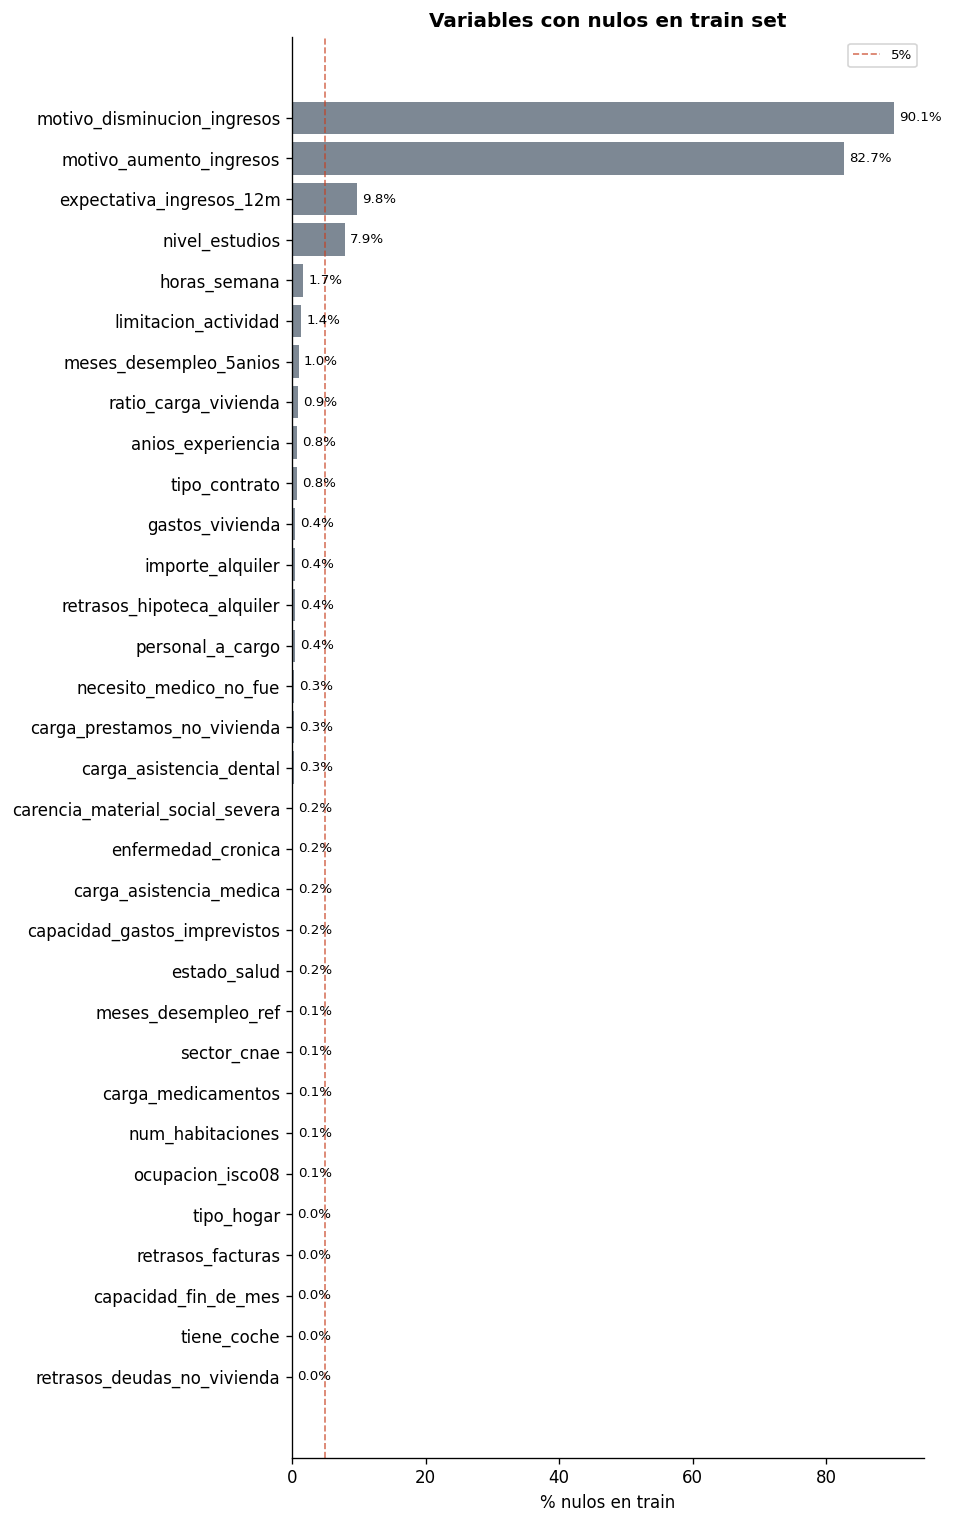

In [6]:
# Mapa de nulos
nulos = train.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
pct   = (nulos / len(train) * 100).round(1)

nulls_map(nulos, pct)

## **2. Distribución del target y desbalanceo**

El desbalanceo es una característica estructural del fenómeno, no un artefacto de muestreo.
Se usará una estrategia de modelado específica: `class_weight='balanced'` en el Pipeline.


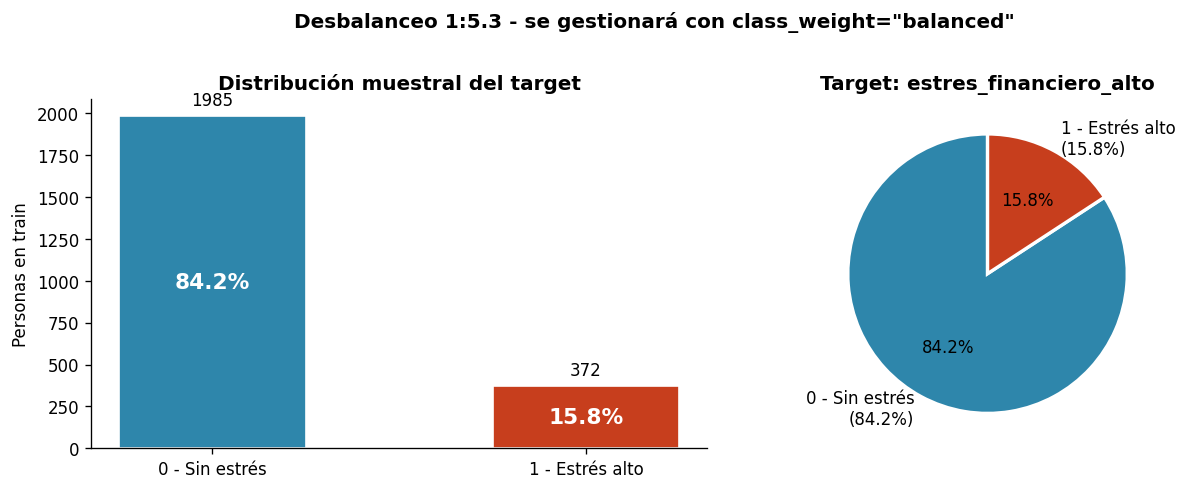

Clase 0: 1,985  (84.2%)
Clase 1: 372  (15.8%)
Ratio de desbalanceo: 1:5.3


In [7]:
vc  = train['estres_financiero_alto'].value_counts().sort_index()
n0, n1 = vc.get(0, 0), vc.get(1, 0)
total  = n0 + n1
target_dis(total, n0, n1)


## **3. Variables demográficas**

In [8]:
# Creación de un diccionario para ir guardando las features estadísticamente más confiables con el target
features_stad = {
    'features': [],
    'importance': []
}

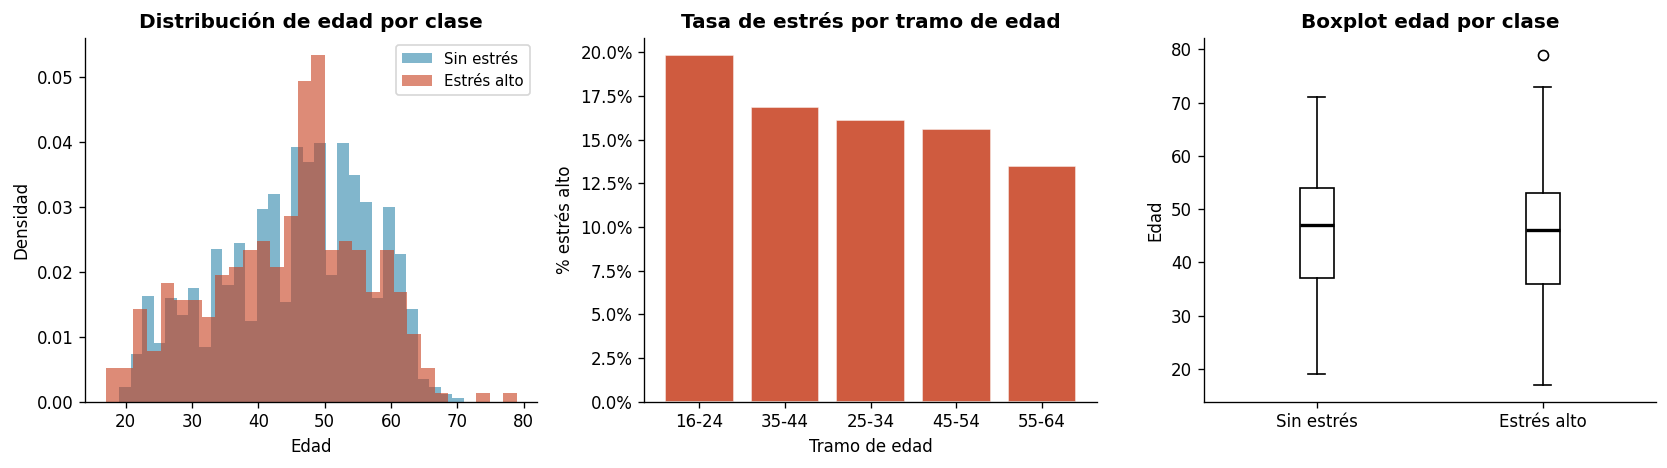

Edad media - sin estrés: 45.5  |  estrés alto: 44.3
Mann-Whitney: U=391292, p=0.0667  -> no significativa


In [9]:
target_age_dis(T0, T1, train, features_stad)

Chi-cuadrado con sexo: U=1, p=0.229457607089906  -> no significativa
Chi-cuadrado con pais_nacimiento: U=120, p=1.1236640352254067e-26  -> diferencia significativa
Chi-cuadrado con nacionalidad: U=32, p=1.2650305833091555e-07  -> diferencia significativa


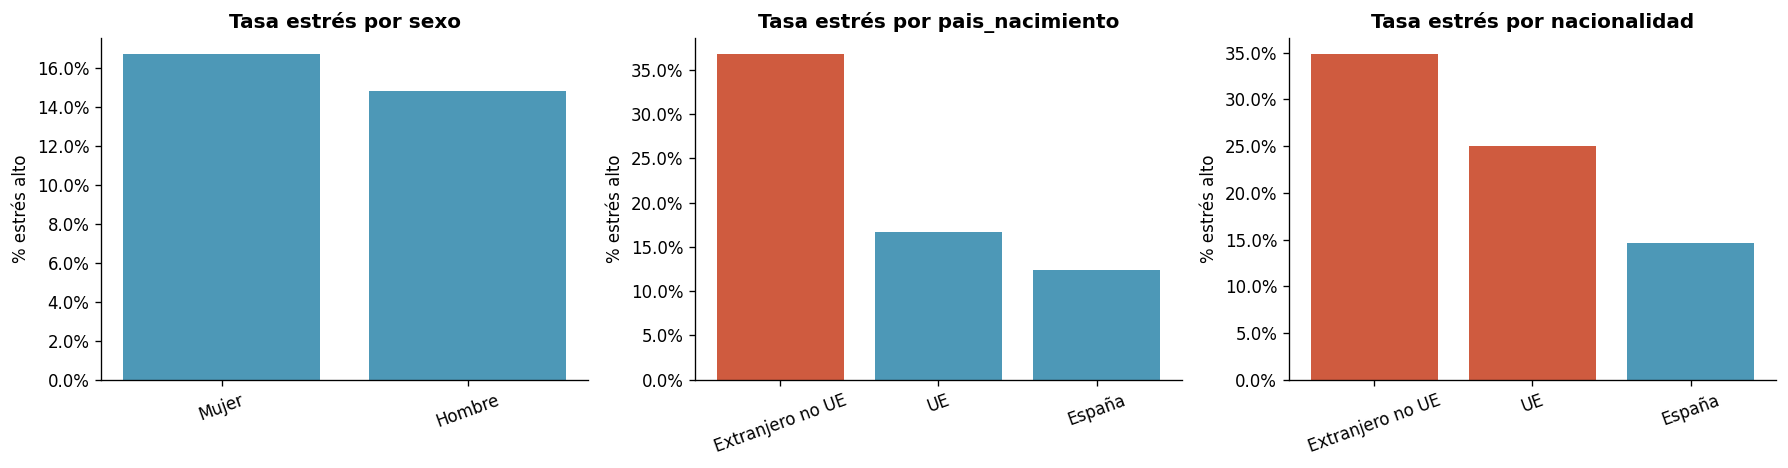

In [10]:
# Sexo, país de nacimiento y nacionalidad
cols_demo = [c for c in ['sexo', 'pais_nacimiento', 'nacionalidad']
             if c in train.columns]

target_vs_var_demo_dis(cols_demo, train, features_stad)

## **4. Variables laborales**

La situación laboral es el grupo de variables de mayor poder predictivo esperado.
Se analizan tipo de contrato, jornada, horas trabajadas, precariedad e historial de desempleo.


Chi-cuadrado con tipo_contrato: U=2, p=0.5158184619983857  -> no significativa
Chi-cuadrado con jornada: U=21, p=4.7238038687142474e-06  -> diferencia significativa
Chi-cuadrado con precariedad_laboral: U=16, p=5.941048615053503e-05  -> diferencia significativa


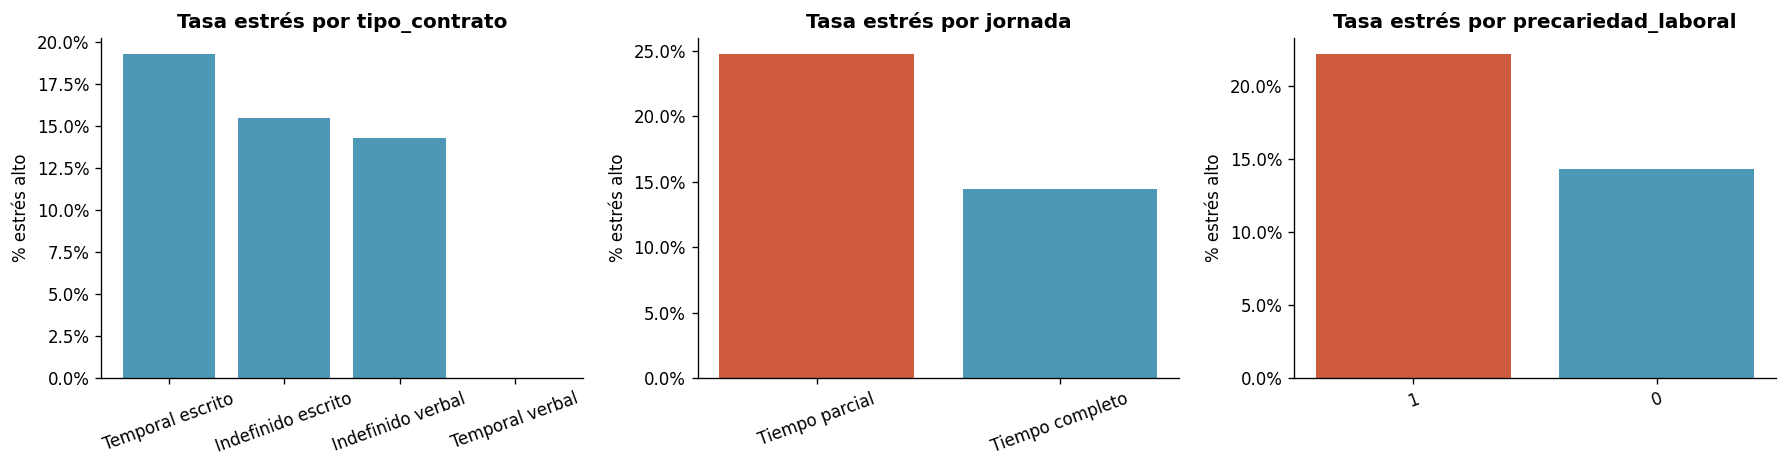

In [11]:
# Tasa de estrés por tipo de contrato y jornada
cols_lab = [c for c in ['tipo_contrato', 'jornada', 'precariedad_laboral']
            if c in train.columns]

target_vs_var_lab(cols_lab, train, features_stad)

Mann-Whitney para horas_semana: U=371254, p=0.2093  -> no significativa
Mann-Whitney para anios_experiencia: U=387354, p=0.0245  -> diferencia significativa


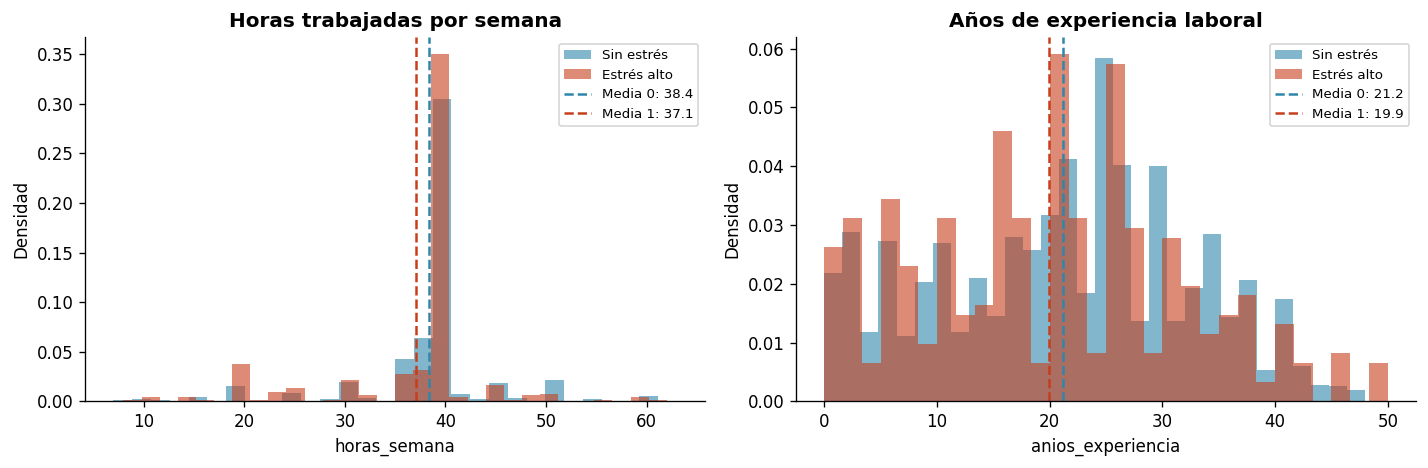

In [12]:
target_vs_hours_exp(train, T0, T1, features_stad)

Mann-Whitney para meses_desempleo_ref: U=357338, p=0.0158  -> diferencia significativa
Mann-Whitney para meses_desempleo_5anios: U=329891, p=0.0001  -> diferencia significativa
meses_desempleo_ref: media sin estrés=0.2  |  estrés alto=0.3


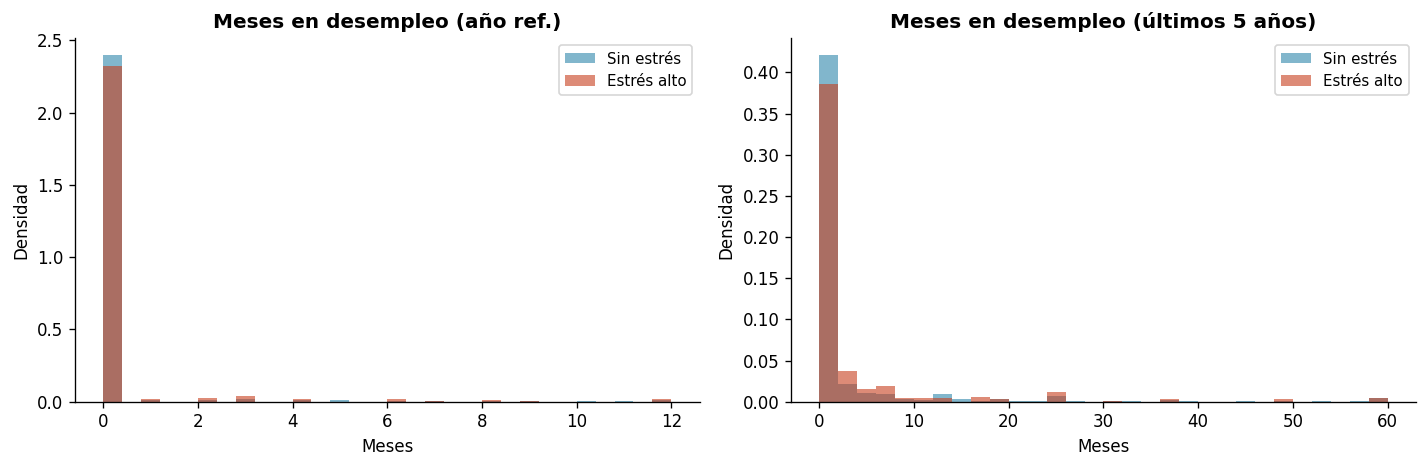

meses_desempleo_5anios: media sin estrés=2.1  |  estrés alto=2.7


<Figure size 768x576 with 0 Axes>

In [13]:
desempleo_vs_target(train, T0, T1, features_stad)

Chi-cuadrado con nivel_estudios: U=104, p=3.201243274420593e-23  -> diferencia significativa


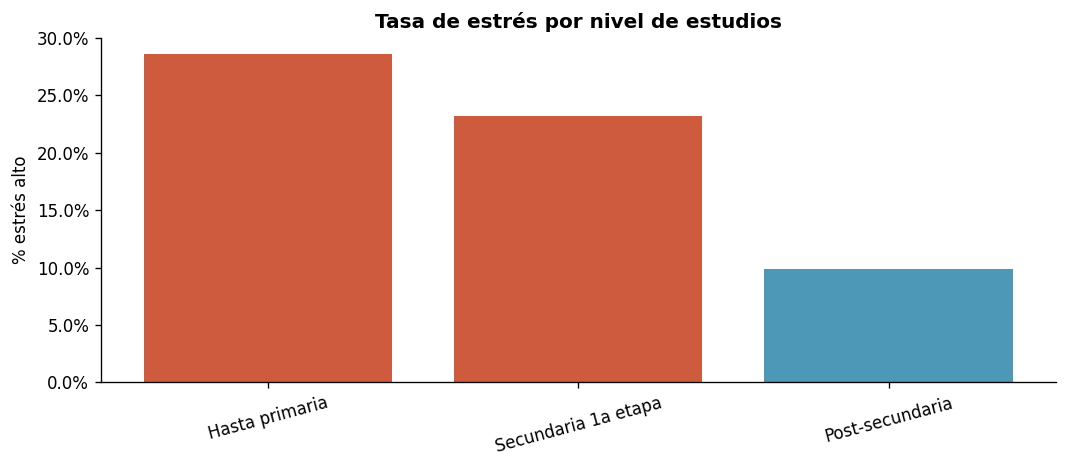

In [14]:
# Nivel de estudios
estudios_vs_target(train, features_stad)

## **5. Variables de renta**

Las variables de renta son las de mayor potencial predictivo y presentan alta asimetría.
Se analiza la distribución, la separación entre clases y la correlación con el target.


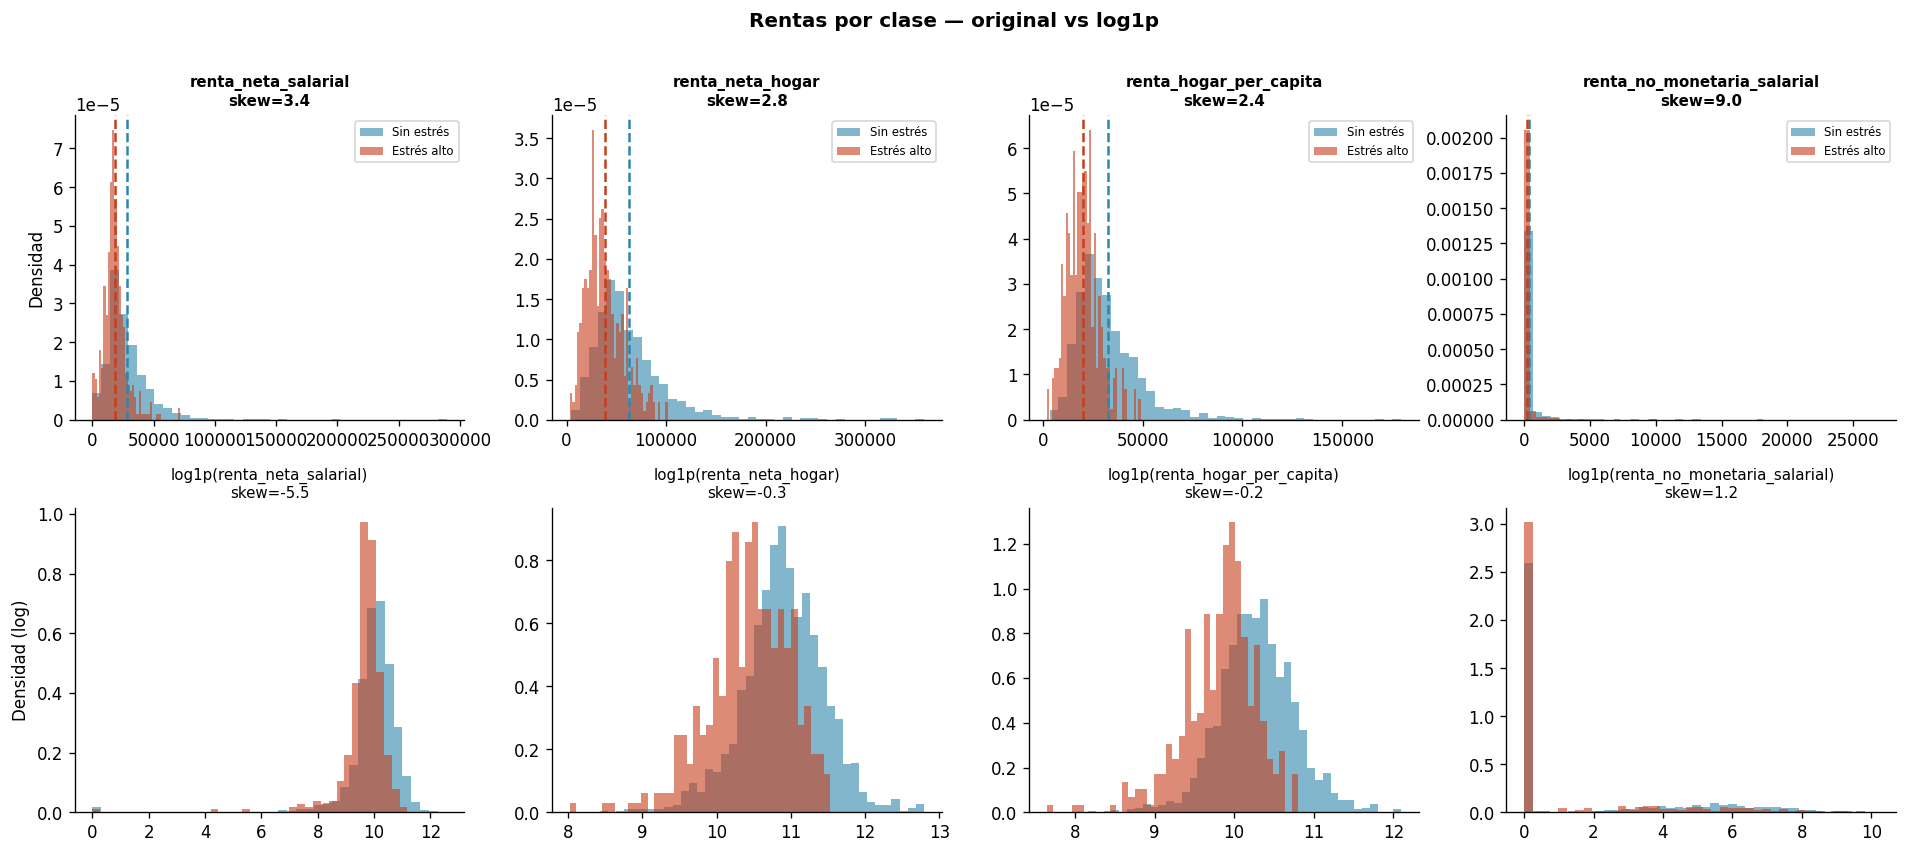

  Variable                              Media sin estrés  Media estrés alto   Ratio    p-valor
  -----------------------------------------------------------------------------------------------
  renta_neta_salarial                            27,973€            18,536€   1.51x    0.0002
  renta_neta_hogar                               62,892€            38,589€   1.63x    0.0002
  renta_hogar_per_capita                         32,845€            20,192€   1.63x    0.0002
  renta_no_monetaria_salarial                       357€               197€   1.81x    0.0002


In [15]:
target_vs_renta(train, T0, T1, features_stad)

In [13]:
train.loc[train['estres_financiero_alto'] == 0, 'renta_neta_salarial'].median()

np.float64(23951.4)

In [15]:
train.loc[train['estres_financiero_alto'] == 0, 'renta_neta_hogar'].median()

np.float64(54185.7)

In [14]:
train.loc[train['estres_financiero_alto'] == 1, 'renta_neta_salarial'].median()

np.float64(17323.2)

In [16]:
train.loc[train['estres_financiero_alto'] == 1, 'renta_neta_hogar'].median()

np.float64(35291.755000000005)

In [20]:
train.loc[(train['estres_financiero_alto'] == 1) & (train['regimen_tenencia'] == 'Alquiler precio reducido'), 'renta_neta_salarial'].median()

np.float64(16595.9)

In [21]:
train.loc[(train['estres_financiero_alto'] == 1) & (train['regimen_tenencia'] == 'Alquiler precio mercado'), 'renta_neta_salarial'].median()

np.float64(15985.1)

In [16]:
# Percentiles de renta por clase
col = 'renta_neta_salarial'
if col in train.columns:
    pcts = [10, 25, 50, 75, 90]
    df_pct = pd.DataFrame({
        'Percentil': [f'P{p}' for p in pcts],
        'Sin estrés': [T0[col].dropna().quantile(p/100) for p in pcts],
        'Estrés alto': [T1[col].dropna().quantile(p/100) for p in pcts],
    })
    print('Percentiles de renta neta salarial por clase (€):')
    print(df_pct.to_string(index=False, float_format=lambda x: f'{x:,.0f}'))

Percentiles de renta neta salarial por clase (€):
Percentil  Sin estrés  Estrés alto
      P10      11,152        8,521
      P25      16,841       13,321
      P50      23,951       17,323
      P75      34,999       21,968
      P90      48,528       28,869


## **6. Variables de vivienda y cargas**

Chi-cuadrado con regimen_tenencia: U=148, p=5.309905098359089e-31  -> diferencia significativa
Chi-cuadrado con tipo_vivienda: U=15, p=0.0016199984802009863  -> diferencia significativa
Chi-cuadrado con tipo_hogar: U=24, p=0.029817353539325783  -> diferencia significativa


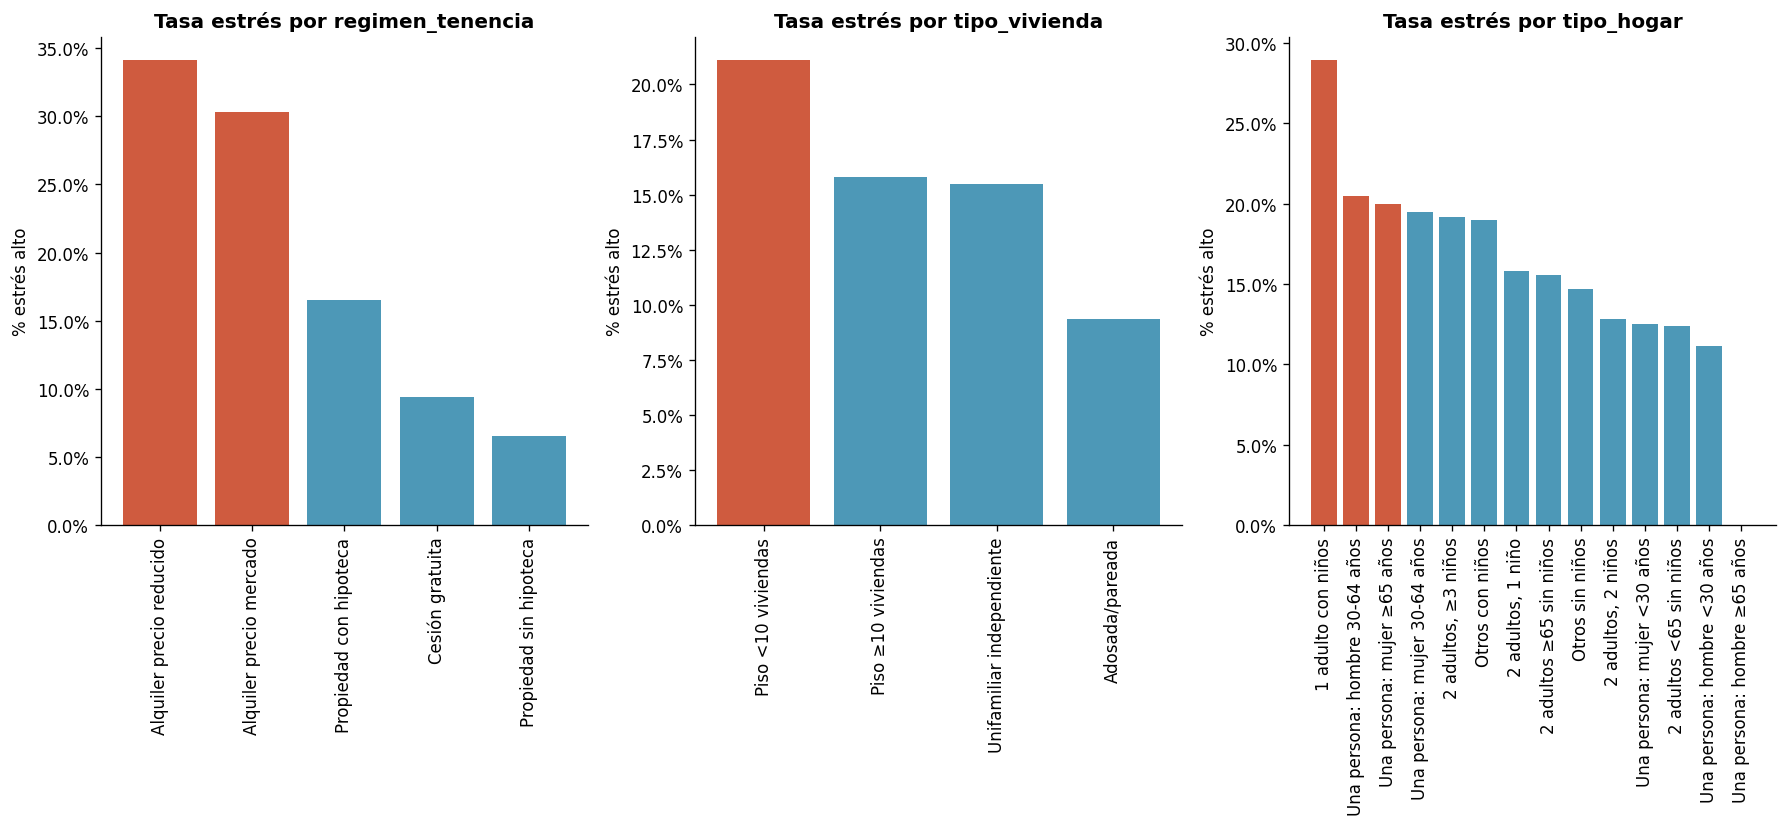

In [17]:
# Régimen de tenencia y tipo de vivienda
target_vs_var_vivienda(train, features_stad)

In [33]:
train.loc[train['tipo_hogar'] == '1 adulto con niños', 'renta_neta_salarial'].median()

np.float64(25510.3)

In [39]:
train.loc[(train['tipo_hogar'] == '1 adulto con niños') & (train['estres_financiero_alto'] == 0),'renta_neta_salarial'].median()

np.float64(30524.4)

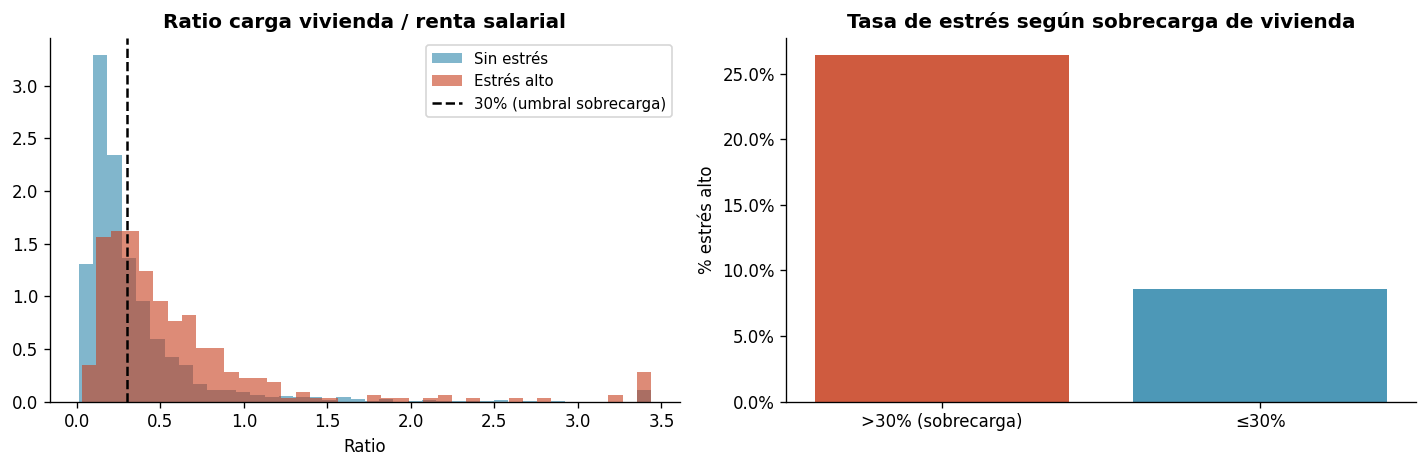

Personas con sobrecarga (>30%): 955 (40.5%)
Ratio medio — sin estrés: 0.35  |  estrés alto: 0.61
Mann-Whitney para ratio_carga_vivienda: U=207255, p=4.1300118745334265e-39  -> diferencia significativa


In [18]:
target_vs_carga_vivienda(train, T0, T1, features_stad)

## **7. Variables de privación material y salud**

Chi-cuadrado con puede_vacaciones: U=616, p=6.236275898429828e-136  -> diferencia significativa
Chi-cuadrado con puede_proteina_2dias: U=172, p=2.4855928443041507e-39  -> diferencia significativa
Chi-cuadrado con puede_calefaccion_invierno: U=350, p=3.593912233833363e-78  -> diferencia significativa
Chi-cuadrado con puede_sustituir_muebles: U=715, p=5.395225217133571e-156  -> diferencia significativa


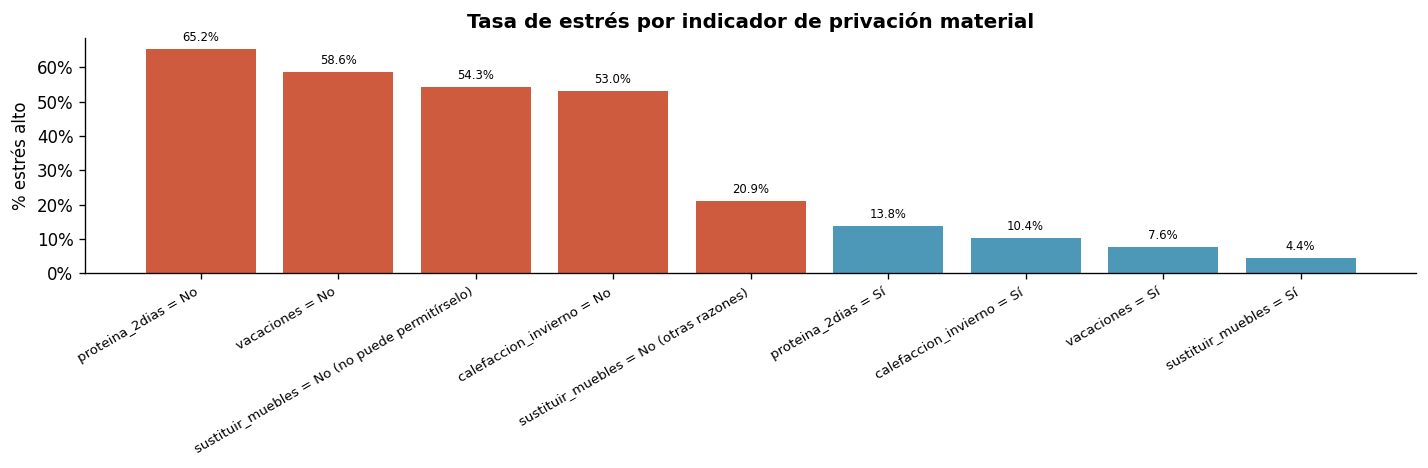

In [19]:
# Privación material
target_var_privacion(train, features_stad)

In [32]:
train.loc[(train['puede_vacaciones'] == 'No') & (train['puede_calefaccion_invierno'] == 'No'), 'estres_financiero_alto'].value_counts(normalize=True)

estres_financiero_alto
1    0.701754
0    0.298246
Name: proportion, dtype: float64

Chi-cuadrado con estado_salud: U=71, p=1.513039926288384e-14  -> diferencia significativa
Chi-cuadrado con limitacion_actividad: U=21, p=2.3016482301884138e-05  -> diferencia significativa


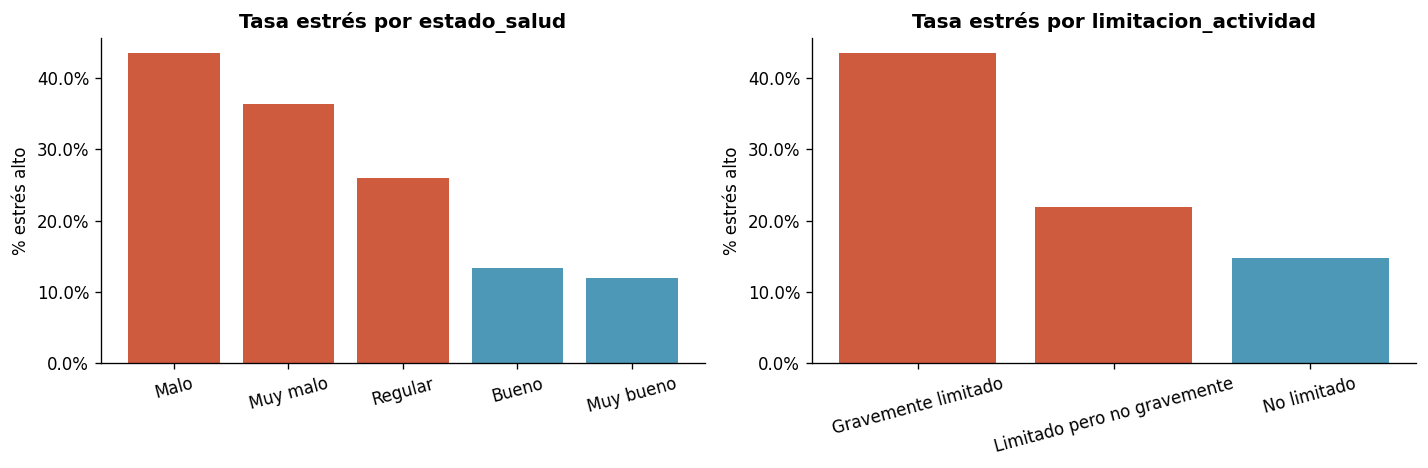

In [20]:
# Salud
target_vs_salud(train, features_stad)

## **8. Variables de dinámica de ingresos**

Chi-cuadrado con cambio_ingresos_12m: U=66, p=4.6413895948569885e-15  -> diferencia significativa


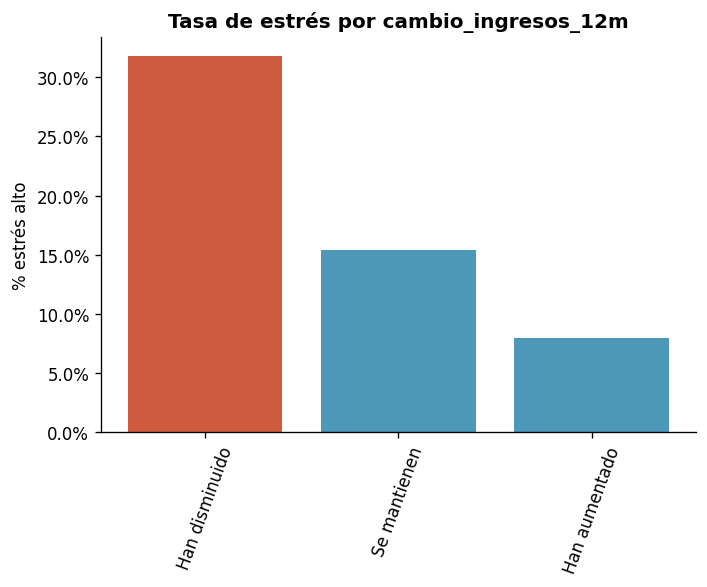

Chi-cuadrado con expectativa_ingresos_12m: U=62, p=3.005057387413916e-14  -> diferencia significativa


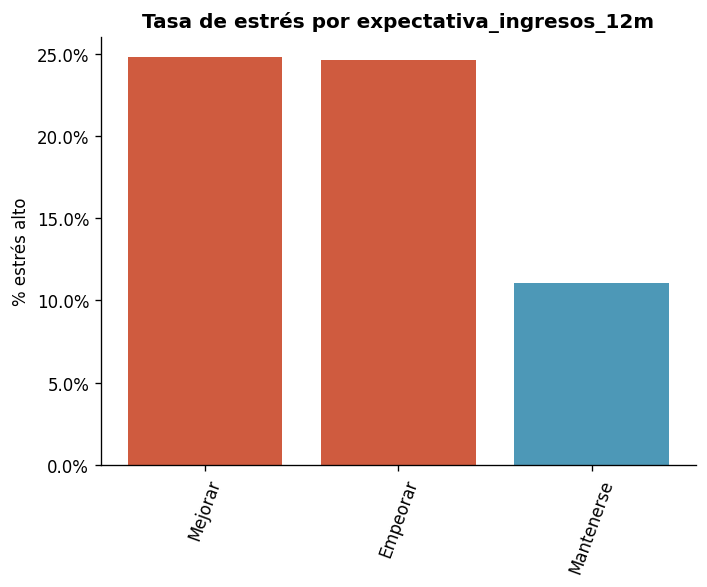

Chi-cuadrado con motivo_aumento_ingresos: U=12, p=0.07231017595581918  -> no significativa


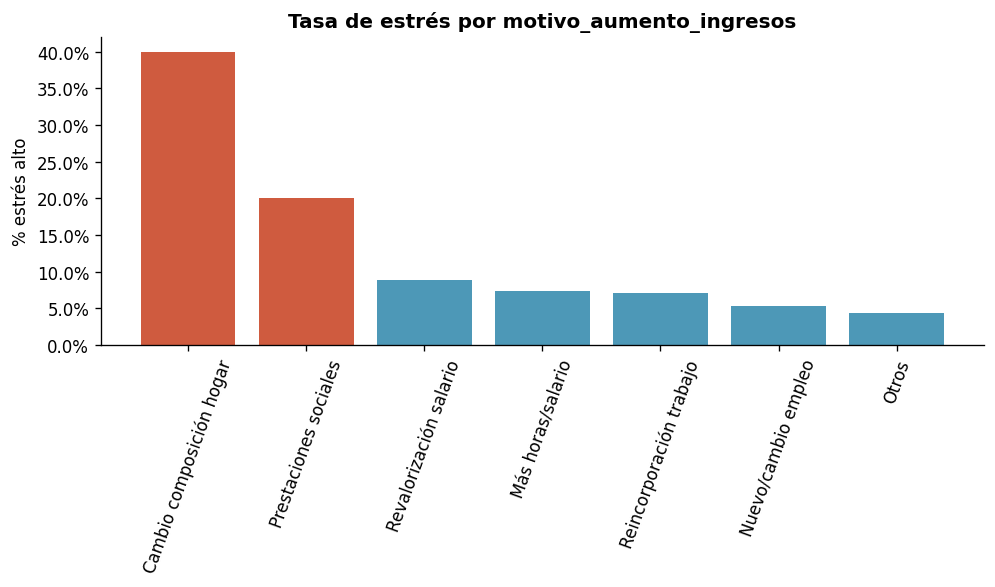

Chi-cuadrado con motivo_disminucion_ingresos: U=17, p=0.02912838772754609  -> diferencia significativa


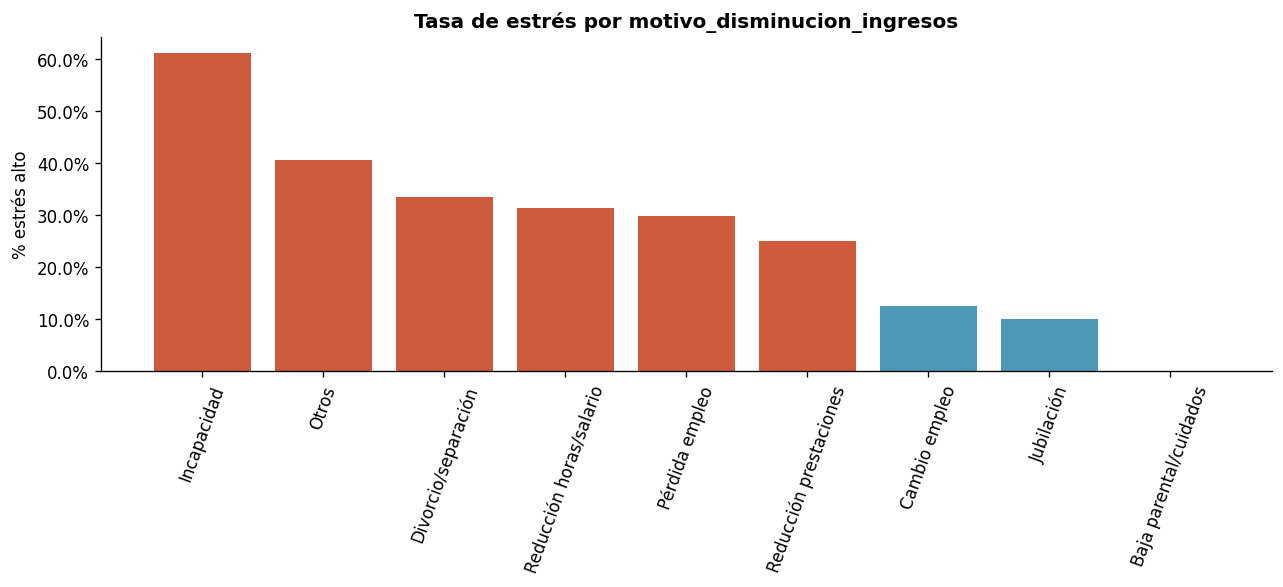

In [21]:
#  Cambio e expectativa de ingresos
target_vs_cambio_empleo(train, features_stad)

## **9. Indicadores de pobreza INE**

Estos indicadores están construidos directamente por el INE a partir de la encuesta.
Alta correlación esperada con el target, pero posible solapamiento semántico.


Chi-cuadrado con hogar_riesgo_pobreza: U=105, p=1.0327184136715997e-24  -> diferencia significativa
Chi-cuadrado con hogar_carencia_material: U=530, p=3.6126045742364255e-117  -> diferencia significativa
Chi-cuadrado con arope_2020: U=448, p=1.7641809911349076e-99  -> diferencia significativa
Chi-cuadrado con arope_2030: U=438, p=3.433636795043751e-97  -> diferencia significativa
Chi-cuadrado con carencia_material_social_severa: U=517, p=1.5278658578591939e-114  -> diferencia significativa
Chi-cuadrado con baja_intensidad_laboral_2020: U=6, p=0.04655260698969315  -> diferencia significativa


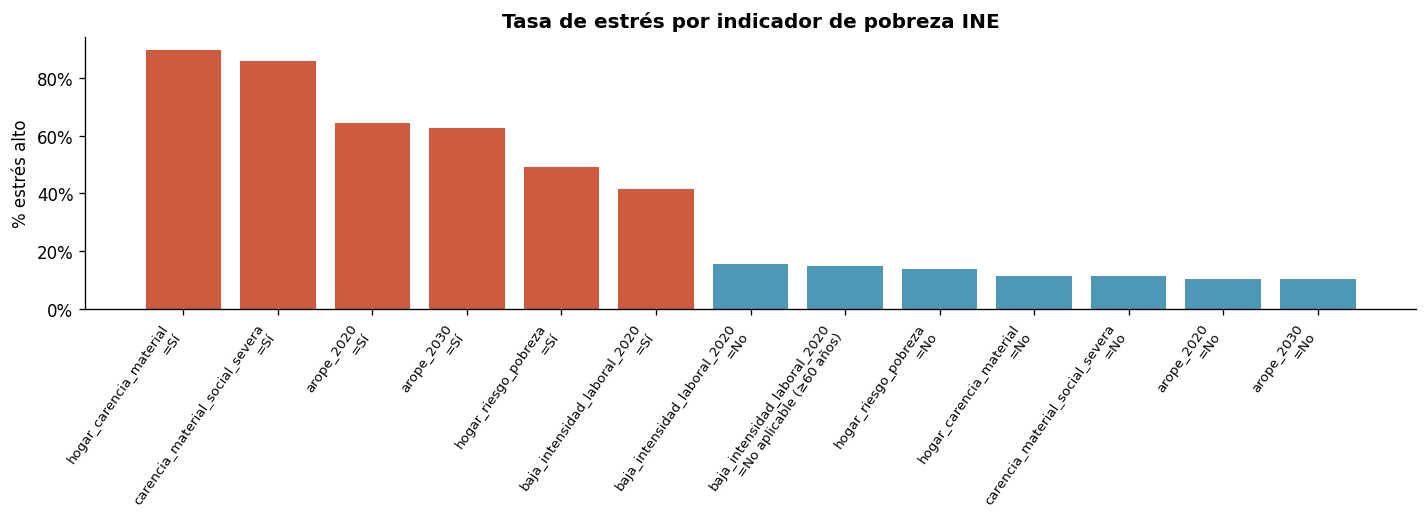

In [22]:
target_vs_INE(train, features_stad)

## **10. Correlaciones y multicolinealidad**
Se usa correlación de Spearman (robusta a no normalidad y outliers) sobre las variables numéricas del train.
Se identifican pares altamente correlacionados (|ρ| > 0.7) que podrían causar problemas en modelos lineales.

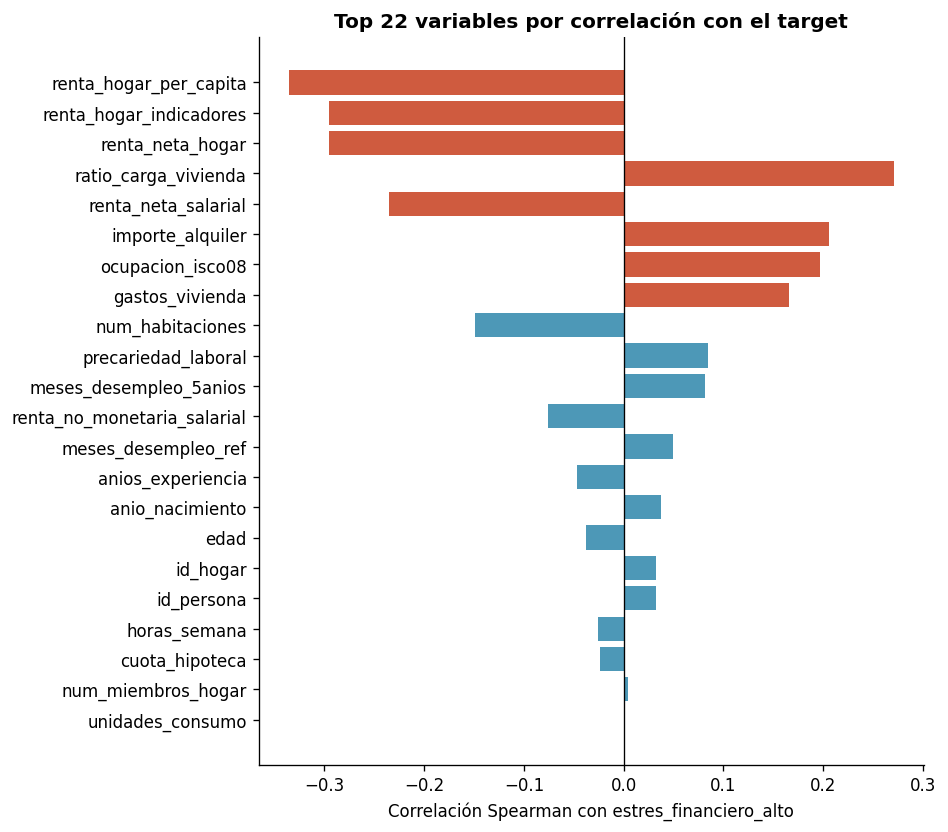

Top 15 correlaciones con el target:
renta_hogar_per_capita        -0.335766
renta_hogar_indicadores       -0.295139
renta_neta_hogar              -0.295139
ratio_carga_vivienda           0.270802
renta_neta_salarial           -0.235417
importe_alquiler               0.205606
ocupacion_isco08               0.197201
gastos_vivienda                0.165537
num_habitaciones              -0.148730
precariedad_laboral            0.084194
meses_desempleo_5anios         0.081101
renta_no_monetaria_salarial   -0.075911
meses_desempleo_ref            0.049736
anios_experiencia             -0.046550
anio_nacimiento                0.037780


In [23]:
# Correlación de Spearman con el target
features_spearman = corr_spearman(train)

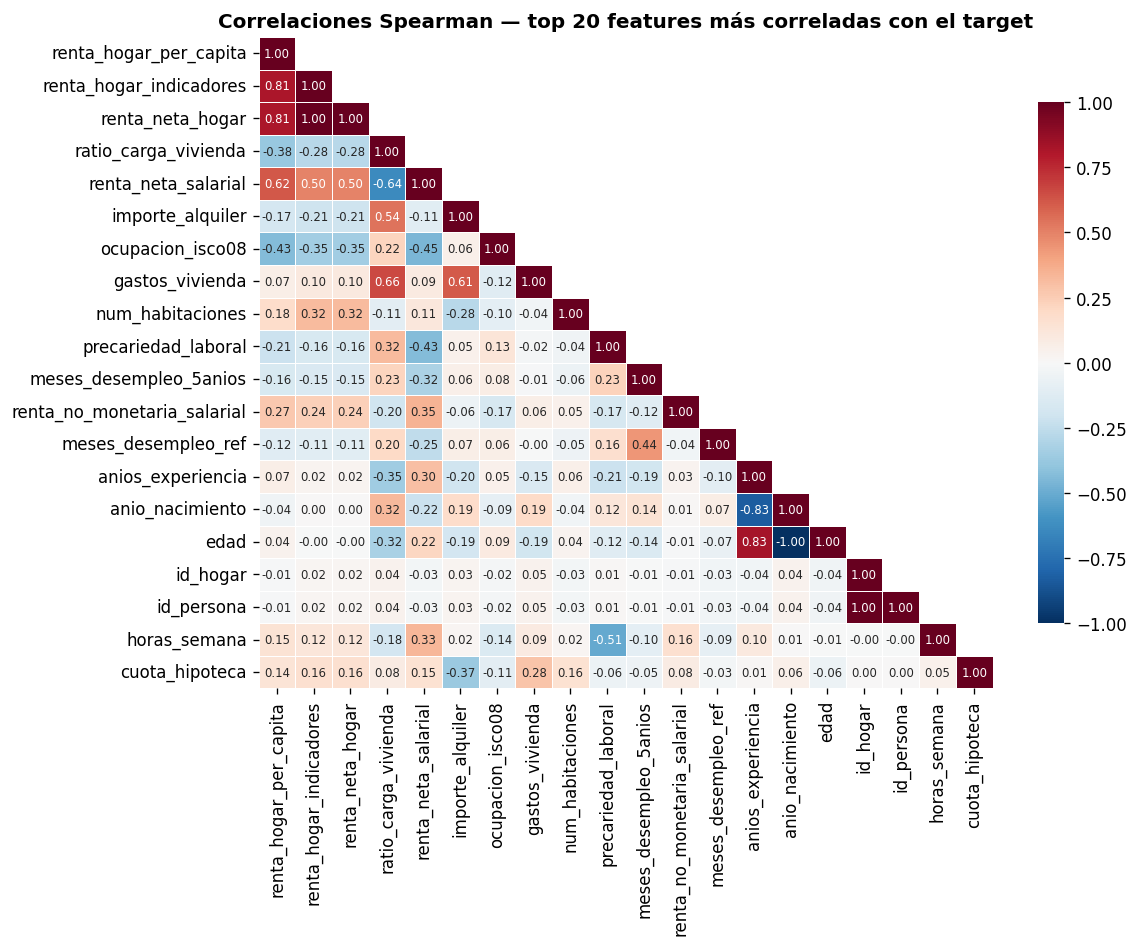

Pares con |ρ| > 0.70 (multicolinealidad alta):
  renta_neta_hogar                    ↔  renta_hogar_indicadores             ρ=1.0
  edad                                ↔  anio_nacimiento                     ρ=-1.0
  id_persona                          ↔  id_hogar                            ρ=1.0
  anio_nacimiento                     ↔  anios_experiencia                   ρ=-0.831
  edad                                ↔  anios_experiencia                   ρ=0.831
  renta_hogar_indicadores             ↔  renta_hogar_per_capita              ρ=0.814
  renta_neta_hogar                    ↔  renta_hogar_per_capita              ρ=0.814


In [24]:
# Heatmap de correlaciones entre features (top 20 más correladas)
pares_altos = corr_pearson(train)

## **11. Análisis de nulos en train**

Los nulos del train son los que el Pipeline debe imputar ajustando parámetros **solo sobre train**.
Se analiza si el patrón de nulos es aleatorio o está relacionado con el target (MNAR).

In [25]:
nulos_train = train.isnull().sum()
nulos_train = nulos_train[nulos_train > 0].sort_values(ascending=False)

print(f'Variables con nulos en train: {len(nulos_train)}')
print()
print(f'  {"Variable":<40} {"N nulos":>8}  {"%":>5}  Tasa observados  Tasa nulos   Flag')
print('  ' + '-' * 90)
for col, n in nulos_train.items():
    pct = n / len(train) * 100
    mask_null = train[col].isna()
    tasa_obs  = train.loc[~mask_null, 'estres_financiero_alto'].mean() * 100
    if mask_null.sum() > 5:
        tasa_null = train.loc[mask_null, 'estres_financiero_alto'].mean() * 100
        flag = '⚠ MNAR?' if abs(tasa_obs - tasa_null) > 10 else ''
        tasa_null_str = f'{tasa_null:.1f}%'
    else:
        tasa_null_str = 'n/a (n≤5)'
        flag = ''
    print(f'  {col:<40} {n:>8,}  {pct:>4.1f}%  {tasa_obs:>14.1f}%  {tasa_null_str:>10}  {flag}')

Variables con nulos en train: 33

  Variable                                  N nulos      %  Tasa observados  Tasa nulos   Flag
  ------------------------------------------------------------------------------------------
  motivo_disminucion_ingresos                 2,123  90.1%            32.5%       13.9%  ⚠ MNAR?
  motivo_aumento_ingresos                     1,950  82.7%             8.1%       17.4%  
  expectativa_ingresos_12m                      230   9.8%            14.8%       24.8%  
  nivel_estudios                                187   7.9%            15.6%       17.6%  
  horas_semana                                   40   1.7%            15.8%       12.5%  
  _tramo_edad                                    33   1.4%            15.7%       21.2%  
  limitacion_actividad                           32   1.4%            15.7%       18.8%  
  meses_desempleo_5anios                         24   1.0%            15.8%       16.7%  
  ratio_carga_vivienda                           22

## **12. Insights**

Esta sección integra los cuatro instrumentos de análisis construidos a lo largo del EDA:

| Instrumento | Qué mide | Variable |
|-------------|----------|----------|
| `features_stad` | Features con asociación estadísticamente significativa con el target (p < 0.05) | Acumulada secciones 3–9 |
| `features_spearman` | Correlación de Spearman con el target (variables numéricas) | Sección 10 |
| `pares_altos` | Pares con multicolinealidad alta (\|ρ\| > 0.70) | Sección 10 |
| `imp` (GBM) | Importancia predictiva no lineal sobre numéricas | Sección 12.3 |

El objetivo es obtener una **lista final de features recomendadas para el Pipeline**,
sin redundancias por multicolinealidad y ordenadas por relevancia para el modelado.

### **12.1 Features con significancia estadística (`features_stad`)**

In [26]:
df_stad = pd.DataFrame(features_stad).sort_values('importance', ascending=False)
print(f'Features con asociación significativa acumuladas en el EDA: {len(df_stad)}')
print()
print(df_stad.to_string(index=False))

Features con asociación significativa acumuladas en el EDA: 36

                       features               importance
                           edad         no significativa
                  tipo_contrato         no significativa
        motivo_aumento_ingresos         no significativa
                   horas_semana         no significativa
                           sexo         no significativa
                     arope_2020 diferencia significativa
        hogar_carencia_material diferencia significativa
                     arope_2030 diferencia significativa
           hogar_riesgo_pobreza diferencia significativa
               puede_vacaciones diferencia significativa
carencia_material_social_severa diferencia significativa
       expectativa_ingresos_12m diferencia significativa
            cambio_ingresos_12m diferencia significativa
           limitacion_actividad diferencia significativa
                   estado_salud diferencia significativa
        puede_sustituir_

In [27]:
df_stad.loc[df_stad['importance'] == 'diferencia significativa', 'features']

32                         arope_2020
31            hogar_carencia_material
33                         arope_2030
30               hogar_riesgo_pobreza
20                   puede_vacaciones
34    carencia_material_social_severa
27           expectativa_ingresos_12m
26                cambio_ingresos_12m
25               limitacion_actividad
24                       estado_salud
23            puede_sustituir_muebles
22         puede_calefaccion_invierno
21               puede_proteina_2dias
29        motivo_disminucion_ingresos
18                         tipo_hogar
19               ratio_carga_vivienda
17                      tipo_vivienda
16                   regimen_tenencia
15        renta_no_monetaria_salarial
14             renta_hogar_per_capita
13                   renta_neta_hogar
12                renta_neta_salarial
11                     nivel_estudios
10             meses_desempleo_5anios
9                 meses_desempleo_ref
8                   anios_experiencia
6           

### **12.2 Correlación Spearman con el target (`features_spearman`)**
Solo variables numéricas. Valor absoluto - el signo indica dirección.

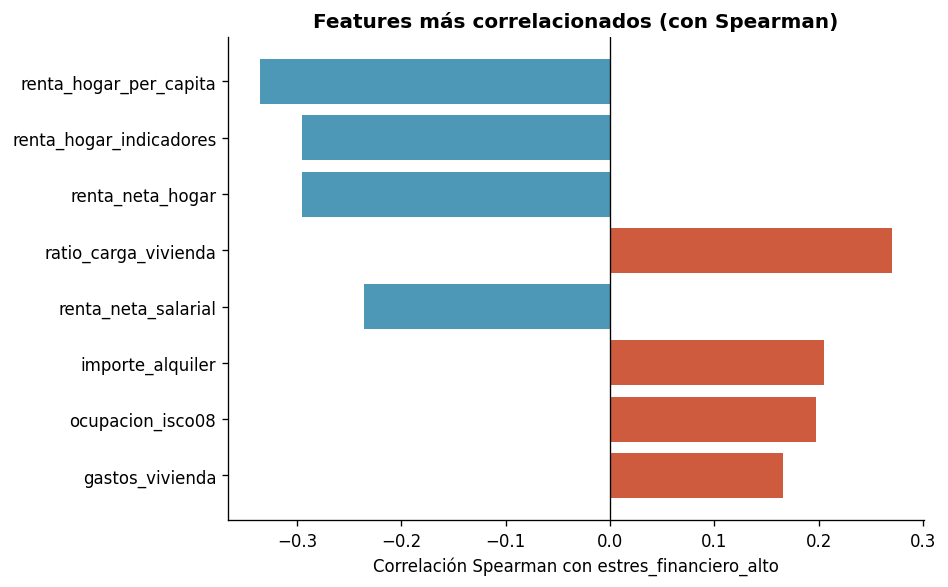

In [28]:
# features_spearman es una Series con index=variable, values=ρ con el target
if isinstance(features_spearman, pd.Series):
    spear = features_spearman.dropna().sort_values(key=abs, ascending=False)
else:
    spear = pd.Series(features_spearman).dropna().sort_values(key=abs, ascending=False)

top_spear = spear.head(25)

fig, ax = plt.subplots(figsize=(8, max(5, len(top_spear) * 0.35)))
colores = [C1 if v > 0 else C0 for v in top_spear.values]
ax.barh(top_spear.index[::-1], top_spear.values[::-1],
        color=colores[::-1], alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Correlación Spearman con estres_financiero_alto')
ax.set_title('Features más correlacionados (con Spearman)', fontweight='bold')
plt.tight_layout()
plt.savefig('src/img/eda_spearman_target.png', bbox_inches='tight')
plt.show()


### **12.3 Importancia GBM preliminar**

El GBM captura relaciones no lineales e interacciones que Spearman no detecta.
Se entrena solo sobre numéricas del train (sin tuning). Orientativo, no definitivo.


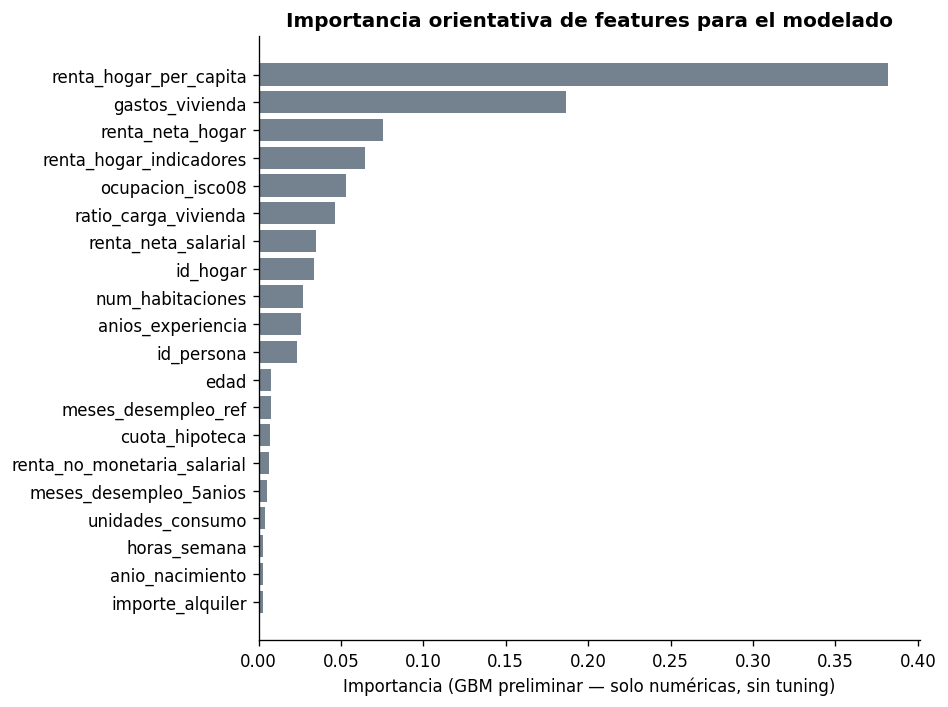

Top 10 features por importancia (GBM preliminar):
renta_hogar_per_capita     0.381983
gastos_vivienda            0.186790
renta_neta_hogar           0.075429
renta_hogar_indicadores    0.064758
ocupacion_isco08           0.053230
ratio_carga_vivienda       0.046673
renta_neta_salarial        0.034708
id_hogar                   0.033714
num_habitaciones           0.027065
anios_experiencia          0.025609


In [36]:
#  Importancia preliminar de features (GBM rápido, solo numéricas)
from sklearn.ensemble import GradientBoostingClassifier
X_num = train.select_dtypes(include='number').drop(
    columns=['estres_financiero_alto'], errors='ignore'
)
X_num_clean = X_num.dropna(axis=1, thresh=int(len(train) * 0.80))
X_num_imp   = X_num_clean.fillna(X_num_clean.median())
y_eda       = train['estres_financiero_alto'].astype(int)

clf = GradientBoostingClassifier(n_estimators=50, max_depth=3, random_state=42)
clf.fit(X_num_imp, y_eda)

imp = pd.Series(clf.feature_importances_, index=X_num_imp.columns)
imp = imp.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp.index[::-1], imp.values[::-1], color=C_NEUTRAL, alpha=0.85)
ax.set_xlabel('Importancia (GBM preliminar — solo numéricas, sin tuning)')
ax.set_title('Importancia orientativa de features para el modelado', fontweight='bold')
plt.tight_layout()
plt.savefig('src/img/eda_importancia_preliminar.png', bbox_inches='tight')
plt.show()

print('Top 10 features por importancia (GBM preliminar):')
print(imp.head(10).to_string())


### **12.4 Selección de features para el Pipeline**

**Criterio de selección en tres pasos:**

1. **Pool inicial** - unión de: features de `features_stad` + top-N de Spearman + top-N de GBM  
2. **Filtro de multicolinealidad** - para cada par en `pares_altos` (|ρ| > 0.70),
   se conserva la feature con mayor importancia GBM y se descarta la otra  
3. **Lista final** - ordenada por importancia GBM (proxy de relevancia para el modelo)

> **Nota:** las variables categóricas de `features_stad` no aparecen en `imp` (GBM solo numéricas).
> Se incluyen igualmente en la lista final si son estadísticamente significativas.

In [30]:
# PASO 1: Pool inicial
# Features estadísticamente significativas (todas las de features_stad)
pool_stad  = set(df_stad['features'].tolist())

# Top por Spearman (|ρ| significativo)
pool_spear = set(spear.head(20).index.tolist())

# Top 20 por GBM
pool_gbm   = set(imp.head(20).index.tolist())

pool_total = pool_stad | pool_spear | pool_gbm
print(f'Pool inicial: {len(pool_total)} features')
print(f'  De features_stad:  {len(pool_stad)}')
print(f'  De Spearman top20: {len(pool_spear)}')
print(f'  De GBM top20:      {len(pool_gbm)}')
print(f'  Solapamiento:      {len(pool_stad & pool_spear & pool_gbm)} en los tres')


Pool inicial: 46 features
  De features_stad:  36
  De Spearman top20: 8
  De GBM top20:      20
  Solapamiento:      4 en los tres


In [31]:
# PASO 2: Filtro de multicolinealidad
# pares_altos es una lista de tuplas (feat_a, feat_b, rho)
# Para cada par, conservar la de mayor importancia GBM; descartar la otra

descartadas = set()

if pares_altos:
    pares_sorted = sorted(pares_altos, key=lambda x: abs(x[2]), reverse=True)
    print('Pares con multicolinealidad alta (|ρ| > 0.70) — decisión de descarte:')
    print(f'  {"Feature A":<35} {"Feature B":<35} {"ρ":>6}  Descartada')
    print('  ' + '-' * 90)
    for a, b, rho in pares_sorted:
        if a in descartadas or b in descartadas:
            continue
        imp_a = imp.get(a, 0)
        imp_b = imp.get(b, 0)
        if imp_a >= imp_b:
            descartadas.add(b)
            descartada_str = b
        else:
            descartadas.add(a)
            descartada_str = a
        print(f'  {a:<35} {b:<35} {rho:>6.3f}  → {descartada_str}')
else:
    print('No hay pares con |ρ| > 0.70 en el pool → no se descarta nada por multicolinealidad')

descartadas.add('id_hogar')

print(f'\nFeatures descartadas por multicolinealidad: {len(descartadas)}')
if descartadas:
    for d in sorted(descartadas):
        if d == 'id_persona' or d == 'id_hogar' :
            print(f'  - {d} (identificador único, no relevante para el modelo)')
        else:
            print(f'  - {d}')

Pares con multicolinealidad alta (|ρ| > 0.70) — decisión de descarte:
  Feature A                           Feature B                                ρ  Descartada
  ------------------------------------------------------------------------------------------
  renta_neta_hogar                    renta_hogar_indicadores              1.000  → renta_hogar_indicadores
  edad                                anio_nacimiento                     -1.000  → anio_nacimiento
  id_persona                          id_hogar                             1.000  → id_persona
  edad                                anios_experiencia                    0.831  → edad
  renta_neta_hogar                    renta_hogar_per_capita               0.814  → renta_neta_hogar

Features descartadas por multicolinealidad: 6
  - anio_nacimiento
  - edad
  - id_hogar (identificador único, no relevante para el modelo)
  - id_persona (identificador único, no relevante para el modelo)
  - renta_hogar_indicadores
  - renta_neta_ho

In [32]:
# PASO 3: Lista final ordenada
features_finales = pool_total - descartadas

# Ordenar: primero por importancia GBM (si está), luego por |Spearman|, luego resto
def score_feature(f):
    gbm_imp   = imp.get(f, 0)
    spear_abs = abs(spear.get(f, 0)) if f in spear.index else 0
    return (gbm_imp + spear_abs * 0.3)   # GBM pesa más

features_finales_sorted = sorted(features_finales, key=score_feature, reverse=True)

# Clasificar por tipo
cols_cat_train = train.select_dtypes(include='object').columns.tolist()
cols_num_train = train.select_dtypes(include='number').drop(
    columns=['estres_financiero_alto'], errors='ignore').columns.tolist()

FEATURES_NUM = [f for f in features_finales_sorted if f in cols_num_train]
FEATURES_CAT = [f for f in features_finales_sorted if f in cols_cat_train]
FEATURES_OTRAS = [f for f in features_finales_sorted
                  if f not in cols_num_train and f not in cols_cat_train]

print('═' * 65)
print('FEATURES RECOMENDADAS PARA EL PIPELINE')
print('═' * 65)
print(f'Total: {len(features_finales_sorted)}  '
      f'(numéricas: {len(FEATURES_NUM)}, categóricas: {len(FEATURES_CAT)})')
print()
print(f'NUMÉRICAS ({len(FEATURES_NUM)}):')
for i, f in enumerate(FEATURES_NUM, 1):
    gbm   = f'GBM={imp.get(f, 0):.4f}' if f in imp.index else 'GBM=n/a'
    spear_v = f'ρ={spear.get(f, 0):+.3f}' if f in spear.index else 'ρ=n/a'
    print(f'  {i:2d}. {f:<40} {gbm}  {spear_v}')
print()
print(f'CATEGÓRICAS ({len(FEATURES_CAT)}):')
for i, f in enumerate(FEATURES_CAT, 1):
    stad_v = df_stad.loc[df_stad['features']==f, 'importance'].values
    imp_str = f'stad={stad_v[0]}' if stad_v[0] == 'diferencia significativa' else 'stad=n/a'
    print(f'  {i:2d}. {f:<40} {imp_str}')
if FEATURES_OTRAS:
    print(f'\nOTRAS ({len(FEATURES_OTRAS)}): {FEATURES_OTRAS}')


═════════════════════════════════════════════════════════════════
FEATURES RECOMENDADAS PARA EL PIPELINE
═════════════════════════════════════════════════════════════════
Total: 40  (numéricas: 15, categóricas: 25)

NUMÉRICAS (15):
   1. renta_hogar_per_capita                   GBM=0.3820  ρ=-0.336
   2. gastos_vivienda                          GBM=0.1868  ρ=+0.166
   3. ratio_carga_vivienda                     GBM=0.0467  ρ=+0.271
   4. ocupacion_isco08                         GBM=0.0532  ρ=+0.197
   5. renta_neta_salarial                      GBM=0.0347  ρ=-0.235
   6. importe_alquiler                         GBM=0.0025  ρ=+0.206
   7. num_habitaciones                         GBM=0.0271  ρ=n/a
   8. anios_experiencia                        GBM=0.0256  ρ=n/a
   9. meses_desempleo_ref                      GBM=0.0076  ρ=n/a
  10. cuota_hipoteca                           GBM=0.0070  ρ=n/a
  11. renta_no_monetaria_salarial              GBM=0.0062  ρ=n/a
  12. meses_desempleo_5anios       

In [33]:
# Visualización: ranking final
print('\n# Para copiar directamente en gold_ecv.py / pipeline Gold:')
print(f'FEATURES_NUM = {FEATURES_NUM}')
print(f'FEATURES_CAT = {FEATURES_CAT}')



# Para copiar directamente en gold_ecv.py / pipeline Gold:
FEATURES_NUM = ['renta_hogar_per_capita', 'gastos_vivienda', 'ratio_carga_vivienda', 'ocupacion_isco08', 'renta_neta_salarial', 'importe_alquiler', 'num_habitaciones', 'anios_experiencia', 'meses_desempleo_ref', 'cuota_hipoteca', 'renta_no_monetaria_salarial', 'meses_desempleo_5anios', 'unidades_consumo', 'horas_semana', 'precariedad_laboral']
FEATURES_CAT = ['jornada', 'pais_nacimiento', 'hogar_riesgo_pobreza', 'tipo_vivienda', 'arope_2030', 'expectativa_ingresos_12m', 'regimen_tenencia', 'puede_proteina_2dias', 'carencia_material_social_severa', 'puede_sustituir_muebles', 'puede_vacaciones', 'nivel_estudios', 'estado_salud', 'limitacion_actividad', 'hogar_carencia_material', 'arope_2020', 'sexo', 'tipo_contrato', 'cambio_ingresos_12m', 'motivo_disminucion_ingresos', 'motivo_aumento_ingresos', 'baja_intensidad_laboral_2020', 'nacionalidad', 'puede_calefaccion_invierno', 'tipo_hogar']


In [34]:
# Exportar ambas listas en texto plano para usarla directamente en el Pipeline Gold
with open('src/data/03_gold/raw/FEATURES_NUM.txt', 'w', encoding='utf-8') as f:
    for elemento in FEATURES_NUM:
        f.write(f"{elemento},")

In [35]:
with open('src/data/03_gold/raw/FEATURES_CAT.txt', 'w', encoding='utf-8') as f:
    for elemento in FEATURES_CAT:
        f.write(f"{elemento},")

---
## *Resumen de hallazgos*

### **Perfil del asalariado con estrés financiero alto**

| Dimensión | Hallazgo |
|-----------|----------|
| **Renta** | Las rentas (salarial neta, hogar per cápita) son las features más discriminantes. La diferencia de medias entre clases es estructural y altamente significativa (p < 0.001). |
| **Vivienda** | El ratio de carga de vivienda separa claramente las clases. El alquiler concentra mayor tasa de estrés que la propiedad. |
| **Privación material** | Los cuatro indicadores (vacaciones, proteína, calefacción, muebles) muestran alta asociación con el target, especialmente la incapacidad para afrontar gastos imprevistos. |
| **Empleo** | Contrato temporal y jornada parcial aumentan significativamente la probabilidad de estrés. El historial de desempleo también discrimina. |
| **Demografía** | La edad muestra diferencias moderadas. El origen (país de nacimiento) tiene un efecto significativo. |
| **Dinámica ingresos** | La expectativa y el cambio de ingresos son features informativas, especialmente la expectativa de empeoramiento. |

---

### **Implicaciones para el Pipeline Gold**

| # | Decisión | Justificación |
|---|----------|---------------|
| 1 | Eliminación de  `motivo_aumento_ingresos` y `motivo_disminucion_ingresos`| Porcentaje de nulos muy elevado, sin valor para el modelo |
| 2 | `log1p` sobre variables de renta | Skew confirmado en el apartado 5; mejora modelos lineales |
| 3 | `class_weight='balanced'` | Desbalanceo 1:5 estructural, no artefacto |
| 4 | Descartar features redundantes por multicolinealidad | Ver tabla de pares en sección 10 y paso 2 de 12.4 |
| 5 | Incluir `ratio_carga_vivienda` y `renta_hogar_per_capita` | Feature engineering con alto poder discriminante |
| 6 | Variables categóricas nominales → OHE en Pipeline (fit solo sobre train) | `tipo_contrato`, `regimen_tenencia`, etc. |
| 7 | Métricas principales: ROC-AUC y F1 clase 1 | Desbalanceo hace que accuracy sea engañoso |

> **Lista de features para el Pipeline** → generada en la celda 12.4 (`FEATURES_NUM`, `FEATURES_CAT`)
> Copiar directamente en `gold_ecv.py`.
